In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/content/Food_Delivery_Times.csv")

In [5]:
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


**EDA**

In [6]:
df.shape

(1000, 9)

In [7]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [9]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [10]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [11]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

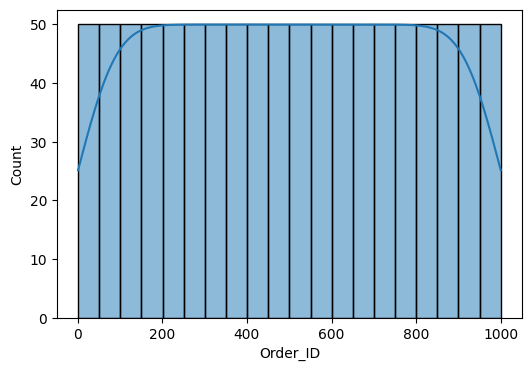

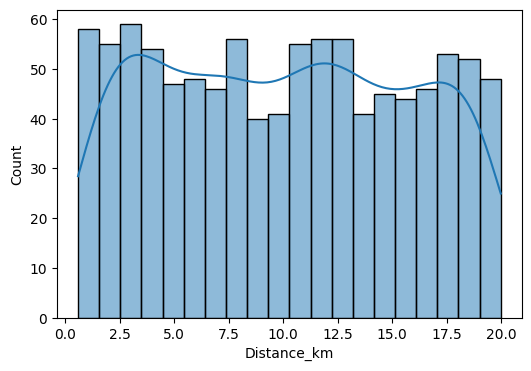

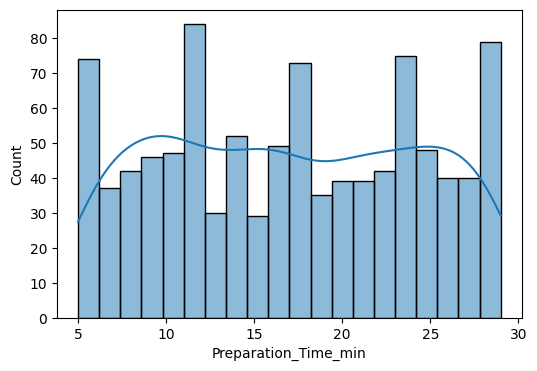

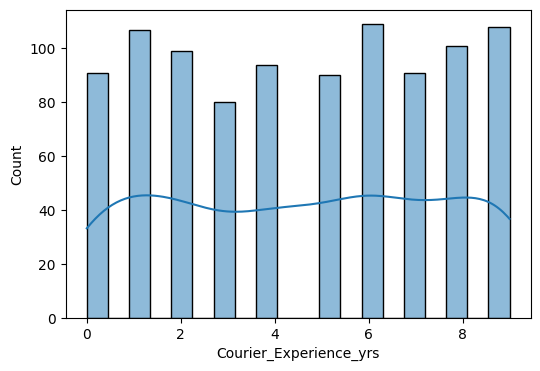

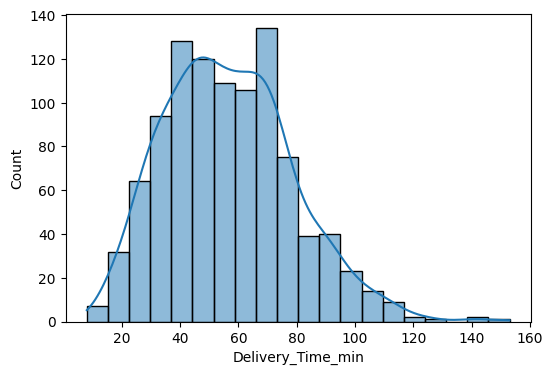

In [12]:
numeric_columns = ['Order_ID', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs','Delivery_Time_min']
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde = True,bins = 20)

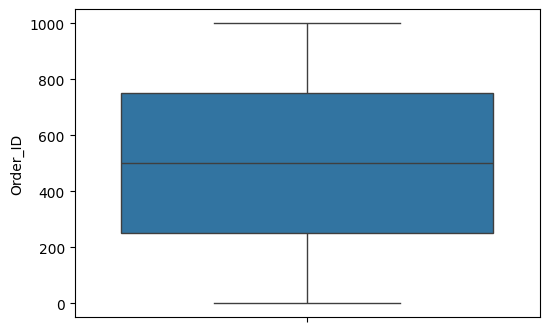

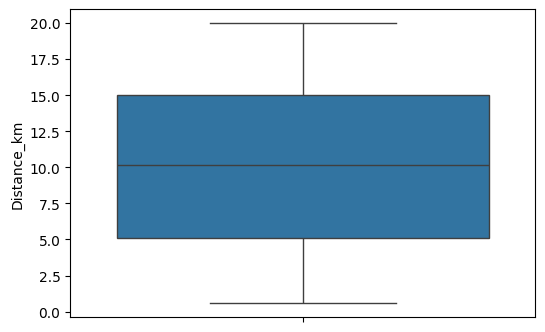

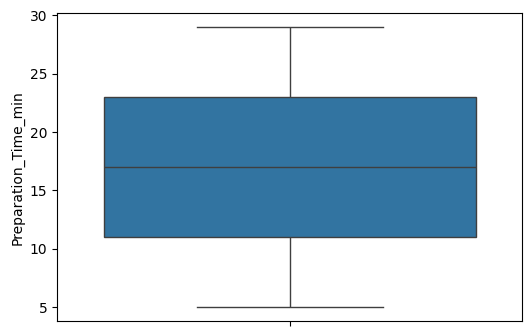

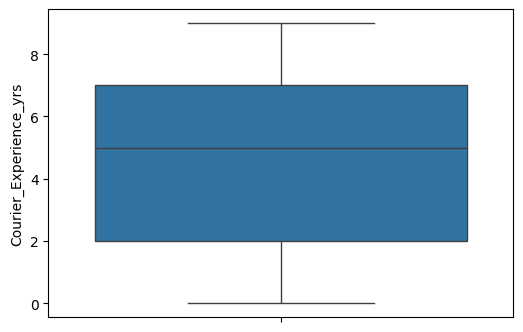

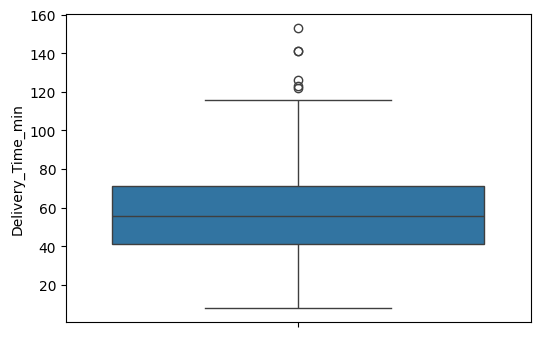

In [13]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[col])


<Axes: >

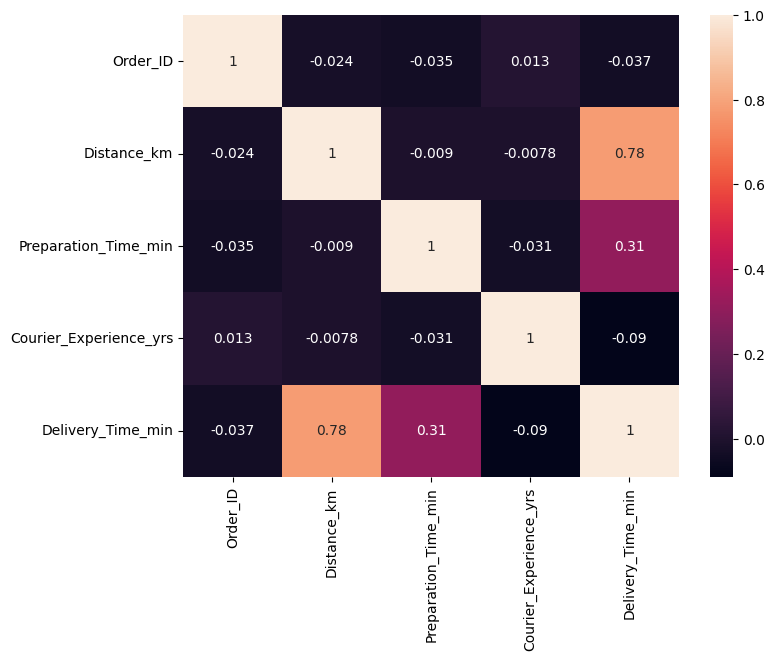

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# ***Data Cleaning and Preprocessing***

In [15]:
df_cleaned = df.copy()

In [16]:
df_cleaned.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [17]:
df_cleaned.shape

(1000, 9)

In [18]:
df_cleaned.drop_duplicates(inplace=True)

In [19]:
df_cleaned.shape

(1000, 9)

In [20]:
df_cleaned.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [21]:
df_cleaned.dtypes

,0
Order_ID,int64
Distance_km,float64
Weather,object
Traffic_Level,object
Time_of_Day,object
Vehicle_Type,object
Preparation_Time_min,int64
Courier_Experience_yrs,float64
Delivery_Time_min,int64


In [22]:
df_cleaned["Delivery_Time_min"].value_counts()

,count
Delivery_Time_min,
71,23
44,22
48,22
43,21
51,21
...,...
103,1
99,1
126,1


In [23]:
# df_cleaned["Delivery_Time_min"] = df_cleaned["Delivery_Time_min"].str.replace("min","")

In [24]:
df_cleaned.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [25]:
df_cleaned["Weather"].value_counts()

,count
Weather,
Clear,470
Rainy,204
Foggy,103
Snowy,97
Windy,96


In [26]:
df_cleaned["Weather"] = df_cleaned["Weather"].map({"Clear": 0, "Rainy": 1})

In [27]:
df_cleaned

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,NaN,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,0.0,Medium,Evening,Bike,20,2.0,84
2,741,9.52,NaN,Low,Night,Scooter,28,1.0,59
3,661,7.44,1.0,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,0.0,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,0.0,High,Evening,Car,13,3.0,54
996,271,16.28,1.0,Low,Morning,Scooter,8,9.0,71
997,861,15.62,NaN,High,Evening,Scooter,26,2.0,81
998,436,14.17,0.0,Low,Afternoon,Bike,8,0.0,55


### Handling Missing Values and Encoding Categorical Features

In [28]:
df_cleaned = df.copy()

In [29]:
# Impute missing numerical values (Courier_Experience_yrs) with the mean
df_cleaned['Courier_Experience_yrs'].fillna(df_cleaned['Courier_Experience_yrs'].mean(), inplace=True)

# Impute missing categorical values (Weather, Traffic_Level, Time_of_Day) with the mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)

display(df_cleaned.isnull().sum())

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [30]:
# Apply one-hot encoding to categorical features
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

display(df_cleaned.head())

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,False,False,False,True,True,False,False,False,False,False,True
1,738,16.42,20,2.0,84,False,False,False,False,False,True,True,False,False,False,False
2,741,9.52,28,1.0,59,True,False,False,False,True,False,False,False,True,False,True
3,661,7.44,5,1.0,37,False,True,False,False,False,True,False,False,False,False,True
4,412,19.03,16,5.0,68,False,False,False,False,True,False,False,True,False,False,False


In [31]:
# Drop Order_ID as it is an identifier and not useful for modeling
df_cleaned.drop('Order_ID', axis=1, inplace=True)

display(df_cleaned.head())

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,12,1.0,43,False,False,False,True,True,False,False,False,False,False,True
1,16.42,20,2.0,84,False,False,False,False,False,True,True,False,False,False,False
2,9.52,28,1.0,59,True,False,False,False,True,False,False,False,True,False,True
3,7.44,5,1.0,37,False,True,False,False,False,True,False,False,False,False,True
4,19.03,16,5.0,68,False,False,False,False,True,False,False,True,False,False,False


### Model Training

In [32]:
from sklearn.model_selection import train_test_split

X = df_cleaned.drop('Delivery_Time_min', axis=1)
y = df_cleaned['Delivery_Time_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 14)
X_test shape: (200, 14)
y_train shape: (800,)
y_test shape: (200,)


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 7.13
Mean Squared Error (MSE): 105.37
Root Mean Squared Error (RMSE): 10.26
R-squared (R2): 0.76


### Feature Importance

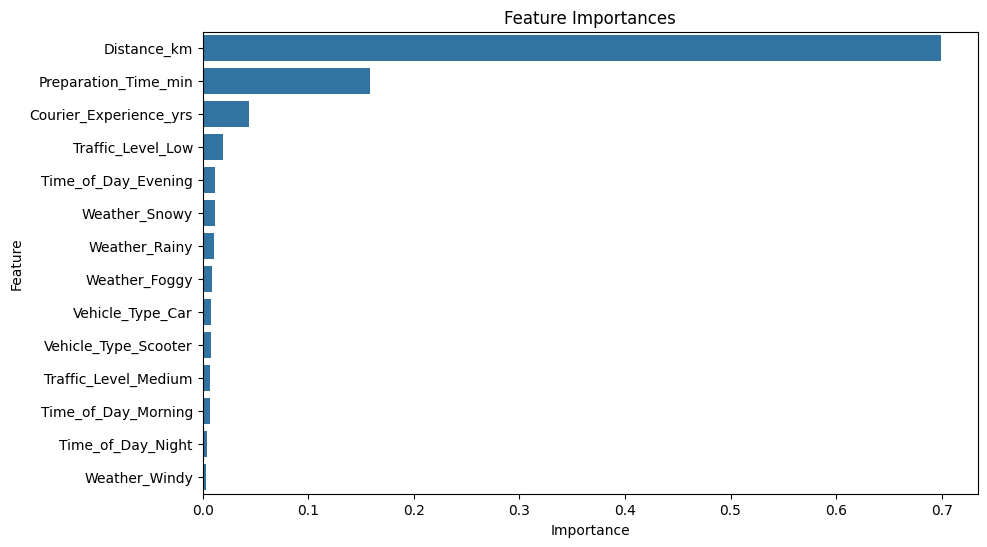

In [34]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Conclusion

In [35]:
print("The Random Forest Regressor model has been trained and evaluated.")
print("Based on the evaluation metrics (MAE, MSE, RMSE, R2) and feature importances, we can understand the key drivers of delivery time.")
print("The model can be further optimized by hyperparameter tuning or trying other advanced models if better performance is required.")

The Random Forest Regressor model has been trained and evaluated.
Based on the evaluation metrics (MAE, MSE, RMSE, R2) and feature importances, we can understand the key drivers of delivery time.
The model can be further optimized by hyperparameter tuning or trying other advanced models if better performance is required.


### Actual vs. Predicted Delivery Times

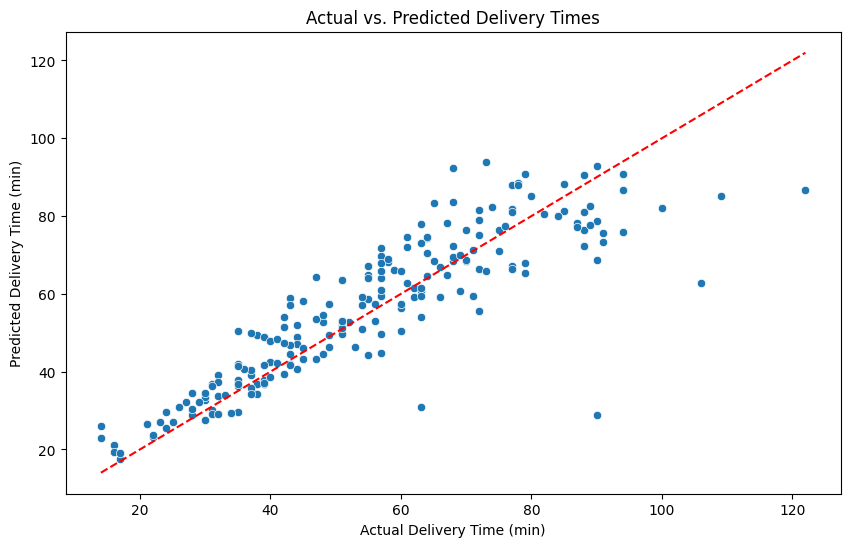

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('Actual vs. Predicted Delivery Times')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Perfect prediction line
plt.show()

### Residual Analysis

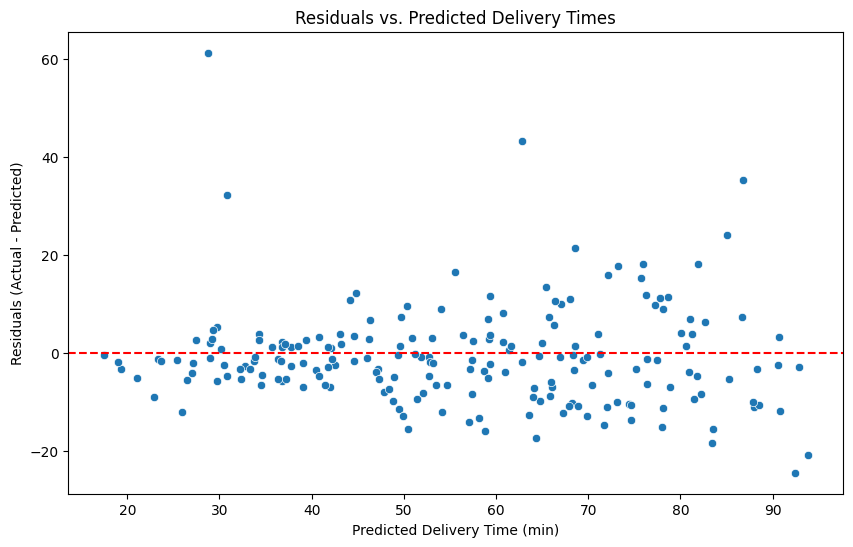

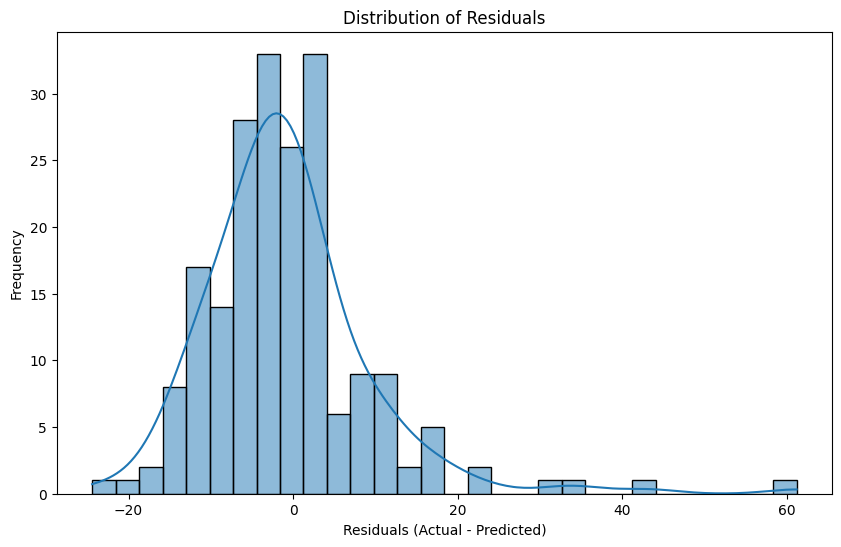

In [39]:
# Calculate residuals
residuals = y_test - y_pred

# Plotting residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Delivery Time (min)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs. Predicted Delivery Times')
plt.show()

# Plotting a histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

In [37]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['squared_error', 'absolute_error']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Score (R-squared on validation sets): {best_score:.2f}")

# Retrain the model with the best parameters
best_model = RandomForestRegressor(**best_params, random_state=42)
best_model.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)

# Evaluate the best model
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("\n--- Best Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_best:.2f}")
print(f"Mean Squared Error (MSE): {mse_best:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best:.2f}")
print(f"R-squared (R2): {r2_best:.2f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'squared_error', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 100}
Best Score (R-squared on validation sets): 0.67

--- Best Model Evaluation ---
Mean Absolute Error (MAE): 8.22
Mean Squared Error (MSE): 122.01
Root Mean Squared Error (RMSE): 11.05
R-squared (R2): 0.73


### Training and Evaluating XGBoost Regressor

In [40]:
from xgboost import XGBRegressor

# Initialize and train the XGBoost model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions with the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("--- XGBoost Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")

print("\n--- Comparison with Random Forest Model (initial) ---")
print(f"Random Forest MAE: {mae:.2f}")
print(f"Random Forest R2: {r2:.2f}")

--- XGBoost Model Evaluation ---
Mean Absolute Error (MAE): 7.92
Mean Squared Error (MSE): 124.99
Root Mean Squared Error (RMSE): 11.18
R-squared (R2): 0.72

--- Comparison with Random Forest Model (initial) ---
Random Forest MAE: 7.13
Random Forest R2: 0.76


### Hyperparameter Tuning for XGBoost Regressor

In [41]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9]
}

# Initialize GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
                               param_grid=param_grid_xgb,
                               cv=3,
                               n_jobs=-1,
                               verbose=2)

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"Best Parameters for XGBoost: {best_params_xgb}")
print(f"Best Score (R-squared on validation sets) for XGBoost: {best_score_xgb:.2f}")

# Retrain the XGBoost model with the best parameters
best_xgb_model = XGBRegressor(objective='reg:squarederror', **best_params_xgb, random_state=42)
best_xgb_model.fit(X_train, y_train)

# Make predictions with the best XGBoost model
y_pred_best_xgb = best_xgb_model.predict(X_test)

# Evaluate the best XGBoost model
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print("\n--- Best Tuned XGBoost Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_best_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_best_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_xgb:.2f}")
print(f"R-squared (R2): {r2_best_xgb:.2f}")

print("\n--- Comparison with Random Forest Model (initial) ---")
print(f"Random Forest MAE: {mae:.2f}")
print(f"Random Forest R2: {r2:.2f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Best Score (R-squared on validation sets) for XGBoost: 0.73

--- Best Tuned XGBoost Model Evaluation ---
Mean Absolute Error (MAE): 6.43
Mean Squared Error (MSE): 87.91
Root Mean Squared Error (RMSE): 9.38
R-squared (R2): 0.80

--- Comparison with Random Forest Model (initial) ---
Random Forest MAE: 7.13
Random Forest R2: 0.76


In [42]:
import joblib

# Define the filename for the best tuned XGBoost model
model_filename_xgb = 'xgboost_regressor_tuned_model.joblib'

# Save the best tuned XGBoost model
joblib.dump(best_xgb_model, model_filename_xgb)

print(f"Best tuned XGBoost model saved to '{model_filename_xgb}'")

Best tuned XGBoost model saved to 'xgboost_regressor_tuned_model.joblib'


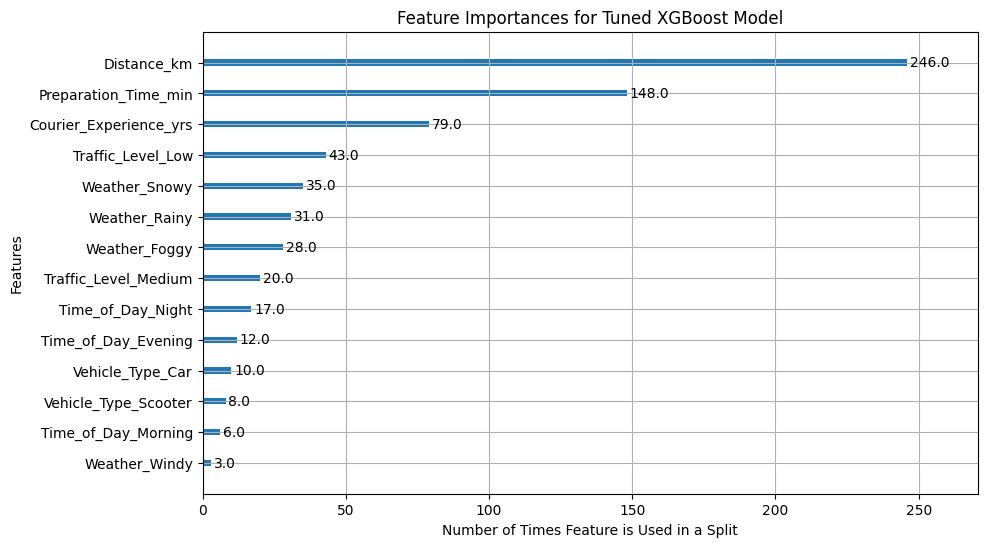

In [43]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importances for the best XGBoost model
fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(best_xgb_model, ax=ax, importance_type='weight') # 'weight' is the number of times a feature is used in a split
plt.title('Feature Importances for Tuned XGBoost Model')
plt.xlabel('Number of Times Feature is Used in a Split')
plt.ylabel('Features')
plt.show()

### Saving the Best Performing Model

In [38]:
import joblib

# Define the filename for the model
model_filename = 'random_forest_regressor_initial_model.joblib'

# Save the initial best-performing model (which was 'model')
joblib.dump(model, model_filename)

print(f"Initial best performing model saved to '{model_filename}'")

Initial best performing model saved to 'random_forest_regressor_initial_model.joblib'


In [46]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [48]:
!git.add

/bin/bash: line 1: git.add: command not found


In [50]:
!git commit -m "Initial Project Commit"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@3473e7716a20.(none)')
